In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/movie dataset pds/movie_dataset.xlsx')


In [ ]:
print(df.head())
print(df.info())
print(df.isnull().sum())


   ID         Movie      Genre  Year  IMDb  Pop  Votes  Runtime  User
0   1     Inception     Sci-Fi  2010   8.8   95   2500      148   9.0
1   2  Interstellar     Sci-Fi  2014   8.7   94   2200      169   8.9
2   3   Dark Knight     Action  2008   9.0   98   2900      152   9.2
3   4      Parasite   Thriller  2019   8.5   88    980      132   8.7
4   5          Coco  Animation  2017   8.4   86    620      105   8.6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       20 non-null     int64  
 1   Movie    20 non-null     object 
 2   Genre    20 non-null     object 
 3   Year     20 non-null     int64  
 4   IMDb     20 non-null     float64
 5   Pop      20 non-null     int64  
 6   Votes    20 non-null     int64  
 7   Runtime  20 non-null     int64  
 8   User     20 non-null     float64
dtypes: float64(2), int64(5), object(2)
memory usage: 1.5+ K

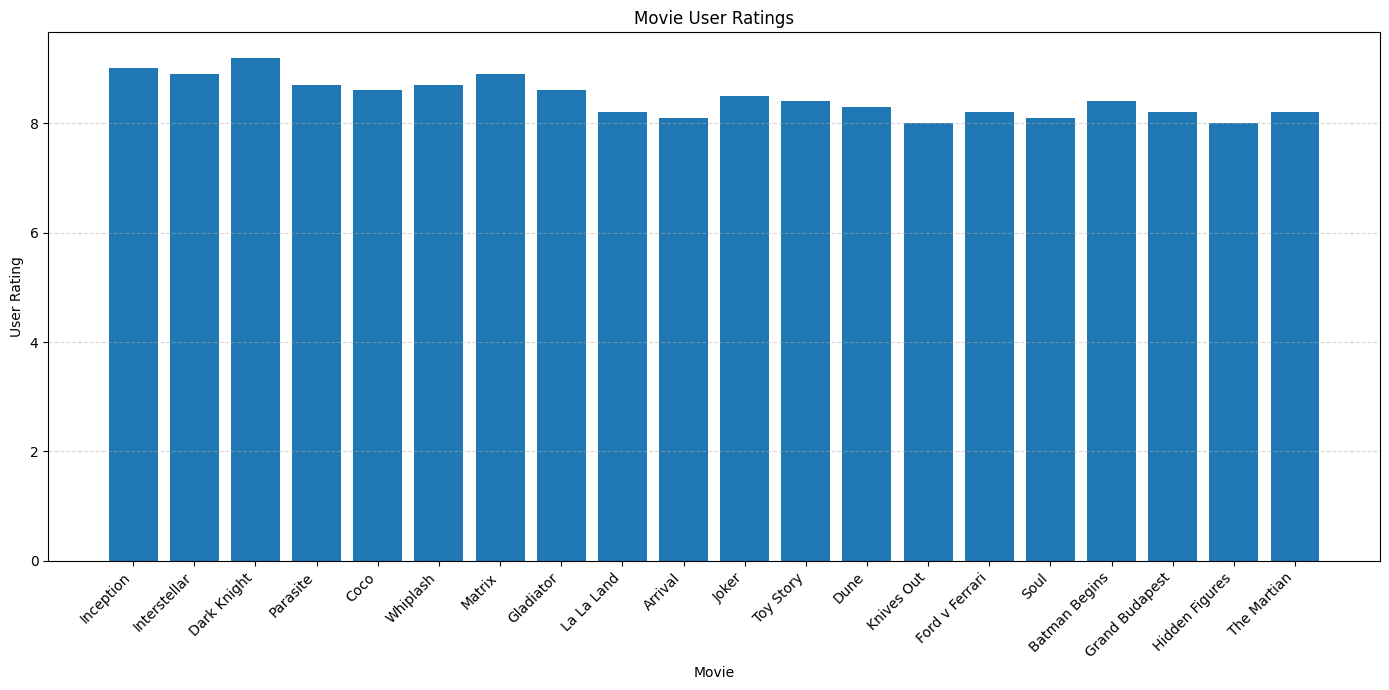

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Numerical arrays and calculations
avg = np.mean(df["User"])

# Visualizes rating trends and predictions
plt.figure(figsize=(14, 7))

plt.bar(df["Movie"], df["User"])

plt.xlabel("Movie")
plt.ylabel("User Rating")
plt.title("Movie User Ratings")

# Make movie names clear
plt.xticks(rotation=45, ha='right')

# Make the graph cleaner
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


R² Score: 0.9931030653343972
Actual vs Predicted Ratings:


,MOVIE,ACTUAL,PREDICTED
0,Inception,9.0,8.98
1,Grand Budapest,8.2,8.23
2,Soul,8.1,8.16
3,Interstellar,8.9,8.89


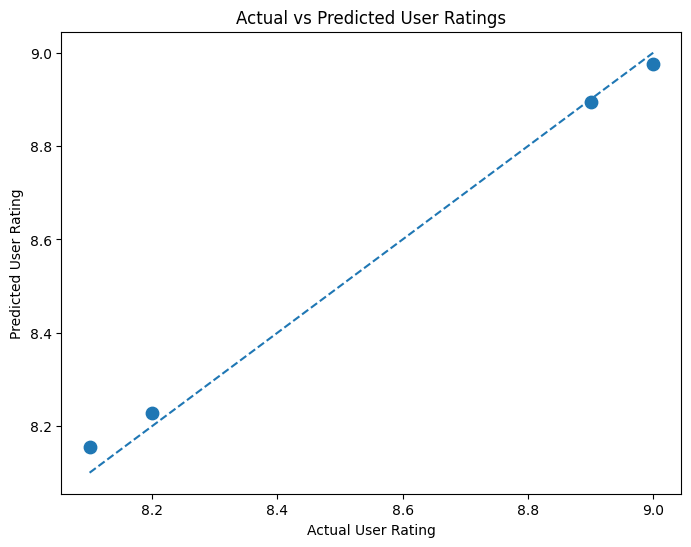

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Correcting column names based on df.info() output
X = df[["IMDb", "Pop", "Votes", "Runtime", "Year"]]
y = df["User"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

results = pd.DataFrame({
    "MOVIE": df.loc[y_test.index, "Movie"].values,
    "ACTUAL": y_test.values,
    "PREDICTED": predictions
})

r2 = r2_score(y_test, predictions)
print("R² Score:", r2)

print("Actual vs Predicted Ratings:")
display(results.round(2))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, s=80)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual User Rating")
plt.ylabel("Predicted User Rating")
plt.title("Actual vs Predicted User Ratings")
plt.show()